<style>
.note {padding: 12px 16px; border-left: 5px solid #2563eb; background: #eff6ff; margin: 10px 0;}
.warn {padding: 12px 16px; border-left: 5px solid #d97706; background: #fffbeb; margin: 10px 0;}
.fix  {padding: 12px 16px; border-left: 5px solid #dc2626; background: #fef2f2; margin: 10px 0;}
.exam {padding: 12px 16px; border-left: 5px solid #059669; background: #ecfdf5; margin: 10px 0;}
table {font-size: 95%;}
</style>

# 07 — ANOVA Fundamentals

### Comparing several means with one coherent model

**Level:** beginner → advanced  
**Style:** short explanations, worked examples, formulas, runnable code, revision material

## What you will be able to do

- explain factors, levels, outcomes, and the omnibus F-test
- distinguish one-way, repeated-measures, and factorial ANOVA
- check assumptions using residual-based thinking
- know what to do after a significant ANOVA

## Resource coverage

- Transcript lines 3837–4170: ANOVA purpose, factors, levels, medicine and payment examples, assumptions
- Transcript lines 4171–4461: one-way, repeated-measures, and factorial ANOVA with medication, running-day, and gender examples
- Topic-map image lines 73–75 identifies ANOVA test, assumptions, and types

<div class="note"><b>How to study this notebook:</b> Read once without memorising. Then rerun the code, solve each checkpoint without looking, and finish with the cheat sheet.</div>


## 1. Why ANOVA?

Analysis of Variance (ANOVA) compares group means by comparing sources of variability.

For a one-way ANOVA with $k$ groups:

$$H_0:\mu_1=\mu_2=\cdots=\mu_k$$

$$H_a:\text{at least one population mean differs}$$

Do **not** write $\mu_1\ne\mu_2\ne\mu_3$. That wrongly claims every pair differs.

Why not run many t-tests?

- Each test creates a chance of Type I error.
- With many pairs, the familywise false-positive risk grows.
- ANOVA first performs one omnibus test of the entire mean structure.

With exactly two independent groups and the matching equal-variance assumptions, one-way ANOVA and the pooled two-sample t-test are equivalent: $F=t^2$.


## 2. Vocabulary

| Term | Meaning | Lecture example |
|---|---|---|
| Response / dependent variable | quantitative outcome being compared | headache rating |
| Factor / independent variable | categorical explanatory variable | medication dosage |
| Level | a category of a factor | 10 mg, 20 mg, 30 mg |
| Group mean | mean response within one level | mean rating for 20 mg |
| Grand mean | mean across all observations | overall headache-rating mean |

The lecture also uses “mode of payment” as a factor with levels such as different payment methods.

<div class="note"><b>Correction in language:</b> factors are variables; levels are categories within a factor. “Independent levels” usually means observations in different groups are independent—not that categories themselves are probabilistically independent.</div>


## 3. The F idea

ANOVA asks whether group means are far apart relative to ordinary within-group noise.

$$F=\frac{\text{variance explained by group differences}}{\text{unexplained variance within groups}}=\frac{MS_B}{MS_W}$$

- If $H_0$ is true, numerator and denominator estimate the same error variance; $F$ tends to be near 1.
- If means are separated, between-group variability grows; $F$ becomes large.
- $F\ge0$ and the ANOVA test is right-tailed.

A large F can arise from large mean differences, low within-group noise, large samples, or a combination.


## 4. Types taught in the lecture

### One-way independent-groups ANOVA

- One factor.
- At least two levels.
- Different, independent observational units in each group.
- Lecture example: different participants receive 10, 20, or 30 mg.

### Repeated-measures ANOVA

- One factor with repeated/dependent measurements.
- Same people measured at two or more times/conditions.
- Lecture example: the same runners measured on day 1, day 2, and day 3.

### Factorial ANOVA

- Two or more factors.
- Estimates **main effects** and **interactions**.
- Lecture example: running day plus gender.

An interaction means the effect of one factor changes across levels of another factor. It is not merely “both factors matter.”


## 5. One-way ANOVA assumptions

The lecture lists normality, no outliers, equal variances, and independent/random samples. Refined version:

1. **Independent observations** within and across independent groups.
2. **Approximately normal residuals** within each group—not necessarily a perfectly normal histogram of all pooled values.
3. **Homogeneity of variances** for classical one-way ANOVA.
4. **No highly influential outliers** or data errors.
5. **Credible sampling/assignment design** for the intended claim.

Important:

- Independence is a design assumption; a histogram cannot prove it.
- ANOVA is often robust to moderate non-normality when group sizes are balanced and not tiny.
- Unequal variances are more dangerous when group sizes are also unequal.


## 6. Assumption checks and alternatives

| Problem | Useful check | Possible response |
|---|---|---|
| non-normal residuals | Q–Q plot; scientific context | transform, bootstrap, robust/rank method |
| unequal variances | group SDs; residual plot; Levene/Brown–Forsythe | Welch ANOVA |
| outliers | boxplot; residual/influence analysis | verify, explain, robust sensitivity analysis |
| dependent observations | inspect design | repeated/mixed model |
| ordinal outcome | measurement meaning | ordinal model or careful rank method |

Avoid ritualistically deleting outliers. First check whether they are errors, valid rare cases, or evidence that the model is wrong.


In [1]:
# Beginner-friendly guide:
# We load tools for calculations, probability distributions, tables, and pictures.
# The next examples compare several group averages with one ANOVA test.
import math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


In [2]:
# Beginner-friendly guide:
# We create three dose groups, summarise each group, then ask whether their average relief ratings differ.
# f_oneway returns the F-ratio and p-value for the all-group comparison.
# Lecture-style one-way data: headache relief rating, higher = more relief
dose_15 = np.array([9, 8, 7, 8, 8, 9, 8])
dose_30 = np.array([7, 6, 6, 7, 8, 6, 7])
dose_45 = np.array([4, 3, 2, 3, 4, 3, 2])

groups = {'15 mg': dose_15, '30 mg': dose_30, '45 mg': dose_45}
summary = pd.DataFrame({
    name: {'n': len(values), 'mean': values.mean(), 'sd': values.std(ddof=1)}
    for name, values in groups.items()
}).T
print(summary.round(3).to_string())

f_stat, p_value = stats.f_oneway(*groups.values())
print(f"\nOne-way ANOVA: F={f_stat:.4f}, p={p_value:.3e}")


         n   mean     sd
15 mg  7.0  8.143  0.690
30 mg  7.0  6.714  0.756
45 mg  7.0  3.000  0.816

One-way ANOVA: F=86.3333, p=5.956e-10


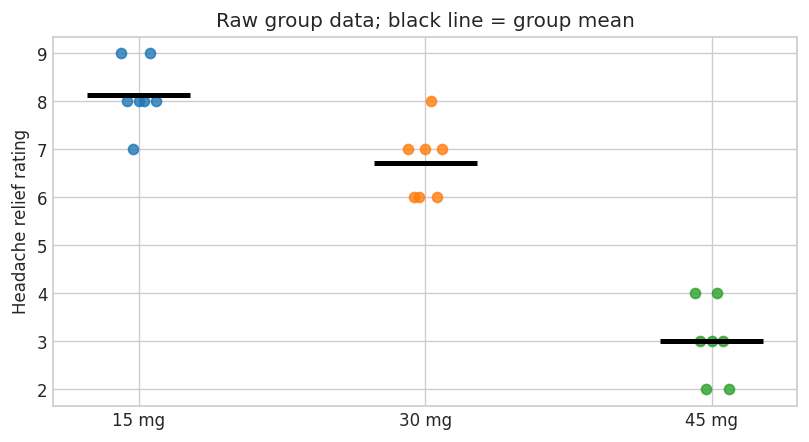

In [3]:
# Beginner-friendly guide:
# We draw every observation instead of hiding the data behind bars alone.
# The black line in each group shows the group average, and the tiny horizontal shift stops dots from covering each other.
# Plot raw observations plus means. Raw data are more informative than bars alone.
plt.figure(figsize=(8, 4))
for i, (name, values) in enumerate(groups.items(), start=1):
    jitter = np.linspace(-0.06, 0.06, len(values))
    plt.scatter(np.full(len(values), i)+jitter, values, alpha=0.8, label=name)
    plt.hlines(values.mean(), i-0.18, i+0.18, color='black', linewidth=3)
plt.xticks([1,2,3], groups.keys())
plt.ylabel('Headache relief rating')
plt.title('Raw group data; black line = group mean')
plt.show()


## 7. What a significant ANOVA does—and does not—tell you

It tells you:

- the equal-means model is not adequate at the chosen level;
- at least one population mean differs.

It does not tell you:

- which groups differ;
- whether every pair differs;
- how important the differences are;
- whether the factor caused them.

Next steps:

- planned contrasts if questions were specified in advance;
- Tukey HSD for all pairwise comparisons under equal-variance assumptions;
- Games–Howell after Welch-type unequal-variance analysis;
- report adjusted confidence intervals and p-values;
- report effect size.


## 8. Effect sizes

### Eta squared

$$\eta^2=\frac{SS_B}{SS_T}$$

Proportion of total sample variability associated with group membership.

### Omega squared

$$\omega^2=\frac{SS_B-(k-1)MS_W}{SS_T+MS_W}$$

Omega squared corrects some upward bias in $\eta^2$.

For factorial/repeated designs, effect-size definitions branch into partial/generalised variants. Always name the exact measure.


## 9. Repeated-measures extra assumption: sphericity

For a within-subject factor with more than two levels, classical repeated-measures ANOVA assumes equal variances of pairwise condition differences.

- Mauchly’s test is commonly reported but can be underpowered or oversensitive.
- Greenhouse–Geisser or Huynh–Feldt corrections adjust degrees of freedom.
- Mixed-effects models are often more flexible, especially with missing observations.

The ordinary independent-groups ANOVA is wrong for repeated observations because measurements from the same person are correlated.


# End-of-topic cheat sheet

| Item | Memory line |
|---|---|
| Purpose | compare several population means |
| Null | all means equal |
| Alternative | at least one differs |
| F | $MS_B/MS_W$ |
| One-way | one factor, independent groups |
| Repeated measures | same units across levels |
| Factorial | 2+ factors; includes interactions |
| Assumptions | independence, normal residuals, variance structure, no dominant outliers |
| Significant omnibus test | follow with planned contrasts/post-hoc analysis |
| Effect size | e.g. $\eta^2$ or $\omega^2$ |

**Key interpretation:** ANOVA compares means by partitioning variance.


# Revision questions and answers

**Q1. What is the one-way ANOVA null hypothesis?**

<details><summary>Answer</summary>

$\mu_1=\mu_2=\cdots=\mu_k$.

</details>

---

**Q2. What is the alternative?**

<details><summary>Answer</summary>

At least one population mean differs; it does not say all pairs differ.

</details>

---

**Q3. Why not run every pairwise t-test without adjustment?**

<details><summary>Answer</summary>

The familywise Type I error rate increases.

</details>

---

**Q4. What does F compare?**

<details><summary>Answer</summary>

Between-group mean-square variability with within-group mean-square variability.

</details>

---

**Q5. What design requires repeated-measures ANOVA?**

<details><summary>Answer</summary>

The same or matched units measured across multiple conditions/times.

</details>

---

**Q6. What is an interaction?**

<details><summary>Answer</summary>

The effect of one factor depends on the level of another factor.

</details>

---

**Q7. Which normality assumption matters?**

<details><summary>Answer</summary>

Approximate normality of model residuals within groups.

</details>

---

**Q8. What should follow a significant omnibus ANOVA?**

<details><summary>Answer</summary>

Planned contrasts or multiplicity-adjusted post-hoc comparisons, plus effect sizes and intervals.

</details>


## Friendly theory: ANOVA compares several group averages with one big fairness check

> **This is an extra, simple-language companion. The detailed notes above stay exactly as they are.**

Imagine three teams playing a game. Their average scores look different, but players inside each team also vary. **ANOVA** asks: are the team averages separated by more than the usual player-to-player wiggle inside teams?

### The F-ratio is a comparison

`F = between-group wiggle ÷ within-group wiggle`

If the group averages are far apart while people inside each group are fairly similar, F gets large. A large F gives evidence that not all population averages are the same.

### One important limit

A significant ANOVA says **at least one** group differs. It does not tell you exactly which pair differs. Follow-up comparisons are needed for that.

### Remember it

**ANOVA is like doing one careful group-comparison test instead of many separate t-tests.** That helps avoid extra false alarms.
